# 08 — 1DCNN vs TCN 성능 비교

두 DL 모델의 `dl_results_{tier}.csv` 결과를 로드해 QLIKE 기준으로 비교.
ML best 결과도 참조선으로 함께 표시.

## 비교 축
- **Protocol**: static / expanding
- **Tier (feature_set)**: core / momentum / extended
- **Regime**: normal / 911 / gfc / covid
- **Country**: US / KR / JP

## 평가 지표
QLIKE (낮을수록 좋음) — ML과 동일한 primary metric.
RMSE, MAE, RMSE_CV도 보조로 표시.

## 전제
- `results/dl_results_{core,momentum,extended}.csv`가 존재해야 함.
- 두 모델 결과가 같은 파일에 있다면 (model 컬럼으로 구분) 그대로 로드.
파일이 없으면 Cell 3 에러 메시지를 확인하세요.

In [1]:
from __future__ import annotations

import sys
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from matplotlib.lines import Line2D

warnings.filterwarnings('ignore')

# ── project root ──────────────────────────────────────────────────────
CWD = Path.cwd().resolve()
PROJECT_ROOT = CWD.parent if CWD.name == 'notebooks' else CWD
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))
print(f'PROJECT_ROOT = {PROJECT_ROOT}')

# ── Google Drive 마운트 (Colab only) ──────────────────────────────────
try:
    from google.colab import drive
    drive.mount('/content/drive')
    # 드라이브 내 FINTEL 경로 — 필요 시 수정
    DRIVE_ROOT = Path('/content/drive/MyDrive/FINTEL')
    if DRIVE_ROOT.exists():
        PROJECT_ROOT = DRIVE_ROOT
        if str(PROJECT_ROOT) not in sys.path:
            sys.path.insert(0, str(PROJECT_ROOT))
        print(f'Drive 마운트 성공 → PROJECT_ROOT = {PROJECT_ROOT}')
    else:
        print(f'Drive 마운트됐으나 {DRIVE_ROOT} 없음 → 로컬 경로 사용')
except ImportError:
    print('로컬 환경 (Colab 아님)')

RESULTS_DIR = PROJECT_ROOT / 'results'
FIGURES_DIR = PROJECT_ROOT / 'results' / 'figures'
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
print(f'결과 디렉토리: {RESULTS_DIR}')

PROJECT_ROOT = /content
Mounted at /content/drive
Drive 마운트 성공 → PROJECT_ROOT = /content/drive/MyDrive/FINTEL
결과 디렉토리: /content/drive/MyDrive/FINTEL/results


## 데이터 로드

`dl_results_{tier}.csv` — 1DCNN, TCN, 기타 DL 결과 (model 컬럼으로 구분)
`ml_results_{tier}.csv` — ML baseline 참조용

In [2]:
TIERS = ['core', 'momentum', 'extended']
DL_MODELS  = ['1DCNN', 'TCN']   # 비교 대상 모델명
MODEL_COLOR = {'1DCNN': '#2563EB', 'TCN': '#DC2626'}
ML_COLOR    = '#6B7280'   # ML 참조선 색

# ── DL 결과 로드 ────────────────────────────────────────────────────
dl_frames = []
for tier in TIERS:
    p = RESULTS_DIR / f'dl_results_{tier}.csv'
    if p.exists():
        df = pd.read_csv(p)
        dl_frames.append(df)
        print(f'  ✔ {p.name}  {len(df):4d} rows  models: {sorted(df["model"].unique())}')
    else:
        print(f'  ✗ {p.name} 없음 (해당 tier 결과 없음)')

if not dl_frames:
    raise FileNotFoundError(
        'dl_results_*.csv 파일이 없습니다.\n'
        '06_1dcnn.ipynb / 07_tcn.ipynb 실행 후 결과를 저장하세요.\n'
        'Colab 사용 중이라면 Drive 마운트 경로를 확인하세요.'
    )

dl_all = pd.concat(dl_frames, ignore_index=True)

# ── ML 결과 로드 (참조용) ────────────────────────────────────────────
ml_frames = []
for tier in TIERS:
    p = RESULTS_DIR / f'ml_results_{tier}.csv'
    if p.exists():
        ml_frames.append(pd.read_csv(p))

ml_all = pd.concat(ml_frames, ignore_index=True) if ml_frames else pd.DataFrame()
print(f'\nDL rows: {len(dl_all)}  |  ML rows: {len(ml_all)}')

# ── 사용 가능 모델 확인 ──────────────────────────────────────────────
available = [m for m in DL_MODELS if m in dl_all['model'].unique()]
missing   = [m for m in DL_MODELS if m not in dl_all['model'].unique()]
print(f'\n비교 대상: {available}')
if missing:
    print(f'⚠ 없는 모델: {missing}  → 해당 모델 노트북을 먼저 실행하세요')

  ✔ dl_results_core.csv   144 rows  models: ['1DCNN', 'TCN']
  ✔ dl_results_momentum.csv   144 rows  models: ['1DCNN', 'TCN']
  ✔ dl_results_extended.csv   144 rows  models: ['1DCNN', 'TCN']

DL rows: 432  |  ML rows: 1080

비교 대상: ['1DCNN', 'TCN']


## 데이터 전처리

- `Full Test` phase만 사용 (sub-phase 제외)
- `is_best_L=True` 행만 사용 (L 튜닝 결과 반영)
- 없는 컬럼은 자동 처리

In [3]:
def prep_dl(df: pd.DataFrame, models=None) -> pd.DataFrame:
    d = df.copy()
    # Full Test만
    d = d[d['phase'] == 'Full Test'].copy()
    # is_best_L 필터 (컬럼 있을 때만)
    if 'is_best_L' in d.columns:
        d = d[d['is_best_L'] == True].copy()
    # 모델 필터
    if models:
        d = d[d['model'].isin(models)].copy()
    return d.reset_index(drop=True)

def prep_ml(df: pd.DataFrame) -> pd.DataFrame:
    if df.empty: return df
    d = df[df['phase'] == 'Full Test'].copy()
    return d.reset_index(drop=True)

dl = prep_dl(dl_all, available)
ml = prep_ml(ml_all)

# ML best: 각 (country, feature_set, protocol)별 QLIKE 최저 모델
if not ml.empty:
    ml_best = (
        ml.groupby(['country', 'feature_set', 'protocol'])['QLIKE']
        .min().reset_index()
        .rename(columns={'QLIKE': 'ML_best_QLIKE'})
    )
else:
    ml_best = pd.DataFrame()

print('DL (is_best_L, Full Test):',  len(dl), 'rows')
print('ML (Full Test):',             len(ml), 'rows')
print('\nDL columns:', list(dl.columns))
print('\n샘플 (5행):')
dl.head()

DL (is_best_L, Full Test): 144 rows
ML (Full Test): 360 rows

DL columns: ['model', 'regime', 'country', 'feature_set', 'L', 'protocol', 'phase', 'RMSE', 'MAE', 'QLIKE', 'RMSE_CV', 'tuning_val_qlike', 'tuning_val_mse', 'tuning_best_epoch', 'final_epochs', 'n_features', 'is_best_L', 'best_val_loss', 'epochs_used', 'n_refits']

샘플 (5행):


,model,regime,country,feature_set,L,protocol,phase,RMSE,MAE,QLIKE,RMSE_CV,tuning_val_qlike,tuning_val_mse,tuning_best_epoch,final_epochs,n_features,is_best_L,best_val_loss,epochs_used,n_refits
0,1DCNN,normal,US,core,60,static,Full Test,0.170312,0.102084,0.027085,0.291092,0.027291,0.028304,47.0,47.0,10,True,NaN,NaN,NaN
1,1DCNN,normal,KR,core,252,static,Full Test,0.108290,0.082646,0.018312,0.203701,0.014557,0.011818,57.0,57.0,10,True,NaN,NaN,NaN
2,1DCNN,normal,JP,core,22,static,Full Test,0.178612,0.121112,0.025906,0.262455,0.014926,0.034098,27.0,27.0,10,True,NaN,NaN,NaN
3,1DCNN,911,US,core,22,static,Full Test,0.251272,0.170483,0.025708,0.238625,0.014634,0.024578,27.0,27.0,10,True,NaN,NaN,NaN
4,1DCNN,911,KR,core,60,static,Full Test,0.506382,0.262822,0.021688,0.358819,0.011858,0.028514,22.0,22.0,10,True,NaN,NaN,NaN


## 종합 요약 테이블

모든 cell의 평균 QLIKE — protocol / tier별.

In [4]:
def summary_table(df: pd.DataFrame, metric='QLIKE') -> pd.DataFrame:
    tbl = (
        df.groupby(['model', 'protocol', 'feature_set'])[metric]
        .mean()
        .unstack('feature_set')
        [TIERS]
    )
    tbl['mean'] = tbl.mean(axis=1)
    return tbl.round(6)

print('=== 평균 QLIKE (낮을수록 ↓ 좋음) ===')
tbl = summary_table(dl)
display(tbl)

# 1DCNN vs TCN 차이
if all(m in available for m in ['1DCNN', 'TCN']):
    print('\n=== QLIKE 차이 (TCN - 1DCNN, 음수=TCN이 나음) ===')
    diff = (
        dl.groupby(['model', 'protocol', 'feature_set'])['QLIKE']
        .mean()
        .unstack('model')
    )
    diff['diff (TCN-1DCNN)'] = diff.get('TCN', np.nan) - diff.get('1DCNN', np.nan)
    display(diff.round(6))

=== 평균 QLIKE (낮을수록 ↓ 좋음) ===


feature_set          core  momentum  extended      mean
model protocol                                         
1DCNN expanding  0.021087  0.022967  0.025786  0.023280
      static     0.023308  0.025860  0.035459  0.028209
TCN   expanding  0.019663  0.021868  0.031214  0.024248
      static     0.021968  0.025217  0.033078  0.026754


=== QLIKE 차이 (TCN - 1DCNN, 음수=TCN이 나음) ===


model                     1DCNN       TCN  diff (TCN-1DCNN)
protocol  feature_set                                      
expanding core         0.021087  0.019663         -0.001425
          extended     0.025786  0.031214          0.005428
          momentum     0.022967  0.021868         -0.001099
static    core         0.023308  0.021968         -0.001340
          extended     0.035459  0.033078         -0.002381
          momentum     0.025860  0.025217         -0.000643

## Win / Tie / Loss (셀 단위)

각 (regime, country, tier, protocol) 조합에서 QLIKE가 낮은 모델에 1점.
동점(± 1e-5) 이내는 Tie.

In [5]:
if all(m in available for m in ['1DCNN', 'TCN']):
    TIE_TOL = 1e-5
    pivot = (
        dl[dl['model'].isin(['1DCNN', 'TCN'])]
        .groupby(['model', 'regime', 'country', 'feature_set', 'protocol'])['QLIKE']
        .mean()
        .unstack('model')
        .dropna(how='any')
        .reset_index()
    )
    pivot['winner'] = np.where(
        (pivot['1DCNN'] - pivot['TCN']).abs() < TIE_TOL, 'tie',
        np.where(pivot['1DCNN'] < pivot['TCN'], '1DCNN', 'TCN'),
    )
    wtl = pivot['winner'].value_counts()
    print('셀 단위 Win/Tie/Loss:')
    print(wtl.to_string())
    total = len(pivot)
    for model in ['1DCNN', 'TCN']:
        wins = wtl.get(model, 0)
        print(f'  {model}: {wins}/{total} wins ({100*wins/total:.1f}%)')
else:
    print('두 모델 결과 모두 필요합니다.')

셀 단위 Win/Tie/Loss:
winner
TCN      39
1DCNN    33
  1DCNN: 33/72 wins (45.8%)
  TCN: 39/72 wins (54.2%)


## Protocol별 QLIKE 비교

Static / Expanding 각각 — 36 cell의 QLIKE 분포 (boxplot + strip).

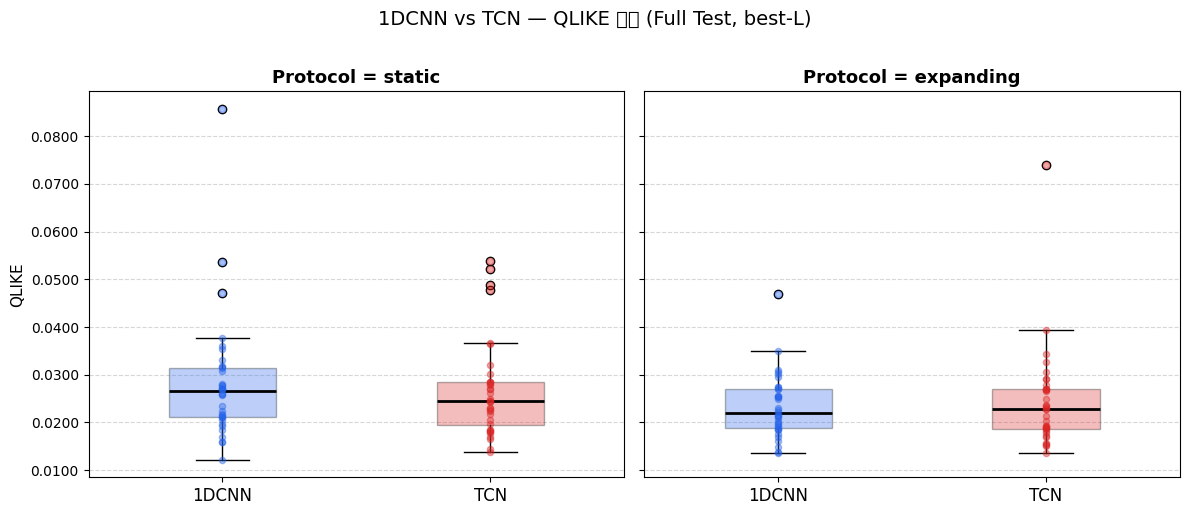

저장: compare_protocol_boxplot.png


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)
protocols = ['static', 'expanding']

for ax, prot in zip(axes, protocols):
    sub = dl[dl['protocol'] == prot]
    if sub.empty:
        ax.set_title(f'{prot} (데이터 없음)')
        continue

    positions = []
    labels = []
    colors = []
    for i, m in enumerate(available):
        vals = sub[sub['model'] == m]['QLIKE'].dropna().values
        positions.append(i)
        labels.append(m)
        colors.append(MODEL_COLOR.get(m, 'gray'))
        ax.scatter([i] * len(vals), vals, alpha=0.4,
                   color=MODEL_COLOR.get(m, 'gray'), s=20, zorder=3)
        bp = ax.boxplot(vals, positions=[i], widths=0.4,
                        patch_artist=True, zorder=2,
                        medianprops=dict(color='black', lw=2))
        bp['boxes'][0].set_facecolor(MODEL_COLOR.get(m, 'gray'))
        bp['boxes'][0].set_alpha(0.3)

    ax.set_xticks(range(len(available)))
    ax.set_xticklabels(available, fontsize=12)
    ax.set_title(f'Protocol = {prot}', fontsize=13, fontweight='bold')
    ax.set_ylabel('QLIKE' if prot == 'static' else '', fontsize=11)
    ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.4f'))
    ax.grid(axis='y', linestyle='--', alpha=0.5)

fig.suptitle('1DCNN vs TCN — QLIKE 분포 (Full Test, best-L)', fontsize=14, y=1.02)
plt.tight_layout()
fig.savefig(FIGURES_DIR / 'compare_protocol_boxplot.png', dpi=150, bbox_inches='tight')
plt.show()
print('저장: compare_protocol_boxplot.png')

## Tier × Protocol 히트맵

cell 단위 QLIKE 평균. 두 모델을 나란히 표시.

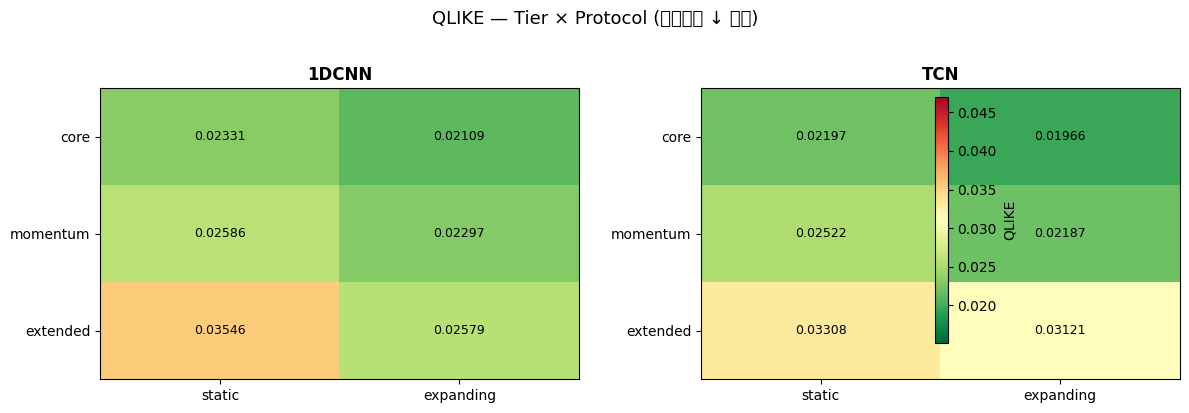

저장: compare_tier_protocol_heatmap.png


In [7]:
import matplotlib.colors as mcolors

def qlike_heatmap(df, model, ax, title, vmin=None, vmax=None, cmap='RdYlGn_r'):
    sub = df[df['model'] == model].copy()
    piv = sub.pivot_table(index='feature_set', columns='protocol', values='QLIKE', aggfunc='mean')
    piv = piv.reindex(index=TIERS, columns=['static', 'expanding'])
    im = ax.imshow(piv.values, cmap=cmap, aspect='auto', vmin=vmin, vmax=vmax)
    ax.set_xticks(range(piv.shape[1]))
    ax.set_xticklabels(piv.columns, fontsize=10)
    ax.set_yticks(range(piv.shape[0]))
    ax.set_yticklabels(piv.index, fontsize=10)
    ax.set_title(title, fontsize=12, fontweight='bold')
    for i in range(piv.shape[0]):
        for j in range(piv.shape[1]):
            val = piv.values[i, j]
            if not np.isnan(val):
                ax.text(j, i, f'{val:.5f}', ha='center', va='center', fontsize=9)
    return im, piv

# 공통 색상 범위
all_q = dl['QLIKE'].dropna()
vmin, vmax = all_q.quantile(0.05), all_q.quantile(0.95)

fig, axes = plt.subplots(1, len(available), figsize=(6 * len(available), 4))
if len(available) == 1:
    axes = [axes]

for ax, m in zip(axes, available):
    im, _ = qlike_heatmap(dl, m, ax, m, vmin=vmin, vmax=vmax)

plt.colorbar(im, ax=axes, label='QLIKE', shrink=0.8)
fig.suptitle('QLIKE — Tier × Protocol (낮을수록 ↓ 좋음)', fontsize=13, y=1.02)
plt.tight_layout()
fig.savefig(FIGURES_DIR / 'compare_tier_protocol_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print('저장: compare_tier_protocol_heatmap.png')

## Regime별 QLIKE 비교

경제 국면(normal / 911 / gfc / covid)별 성능 차이.
각 모델의 평균 QLIKE — 낮을수록 좋음.

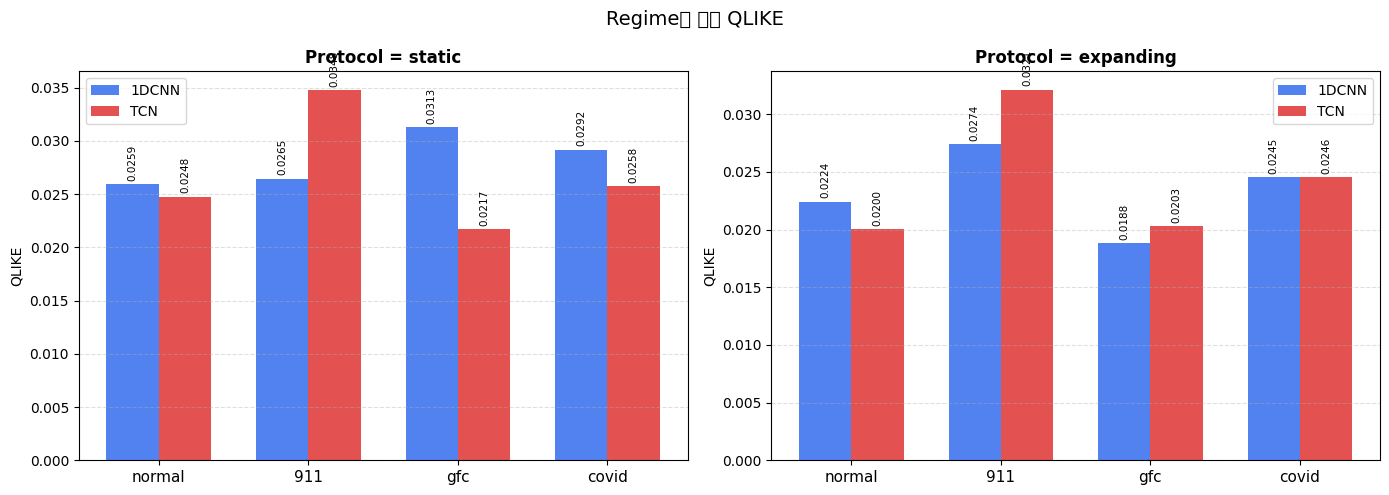

In [8]:
REGIMES = ['normal', '911', 'gfc', 'covid']
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, prot in zip(axes, ['static', 'expanding']):
    sub = dl[dl['protocol'] == prot]
    if sub.empty:
        ax.set_title(f'{prot} (데이터 없음)')
        continue

    regime_q = (
        sub.groupby(['model', 'regime'])['QLIKE']
        .mean().unstack('regime')
        .reindex(columns=REGIMES)
    )

    x = np.arange(len(REGIMES))
    width = 0.35
    for idx, m in enumerate(available):
        if m not in regime_q.index: continue
        offset = (idx - (len(available)-1)/2) * width
        vals = regime_q.loc[m].values
        ax.bar(x + offset, vals, width, label=m,
               color=MODEL_COLOR.get(m, 'gray'), alpha=0.8)
        for xi, v in zip(x + offset, vals):
            if not np.isnan(v):
                ax.text(xi, v + 0.0003, f'{v:.4f}',
                        ha='center', va='bottom', fontsize=7.5, rotation=90)

    ax.set_xticks(x)
    ax.set_xticklabels(REGIMES, fontsize=11)
    ax.set_title(f'Protocol = {prot}', fontsize=12, fontweight='bold')
    ax.set_ylabel('QLIKE', fontsize=10)
    ax.legend(fontsize=10)
    ax.grid(axis='y', linestyle='--', alpha=0.4)

fig.suptitle('Regime별 평균 QLIKE', fontsize=14)
plt.tight_layout()
fig.savefig(FIGURES_DIR / 'compare_regime_bar.png', dpi=150, bbox_inches='tight')
plt.show()

## Country별 QLIKE 비교

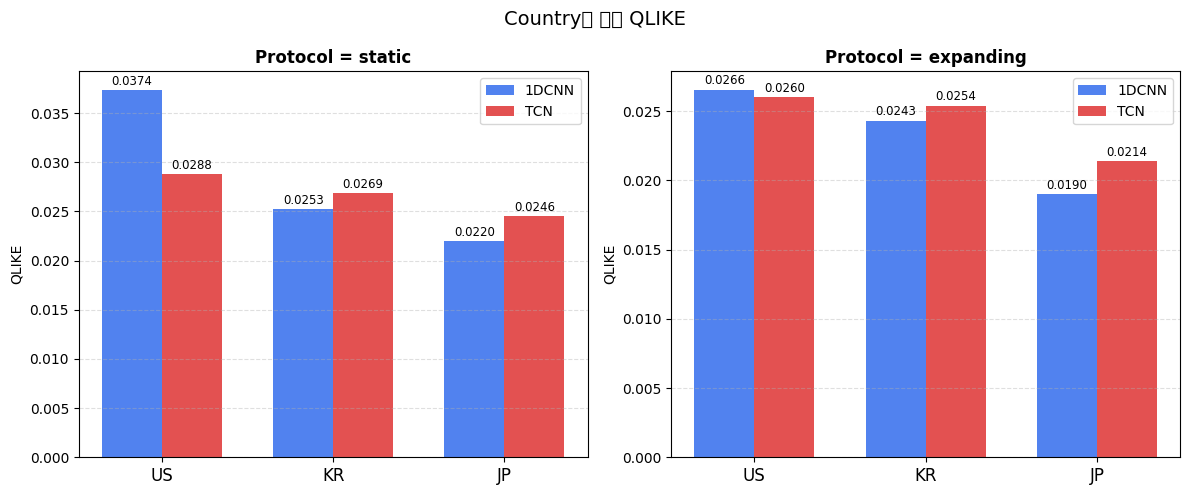

In [9]:
COUNTRIES = ['US', 'KR', 'JP']
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, prot in zip(axes, ['static', 'expanding']):
    sub = dl[dl['protocol'] == prot]
    if sub.empty:
        ax.set_title(f'{prot} (데이터 없음)')
        continue

    country_q = (
        sub.groupby(['model', 'country'])['QLIKE']
        .mean().unstack('country')
        .reindex(columns=COUNTRIES)
    )

    x = np.arange(len(COUNTRIES))
    width = 0.35
    for idx, m in enumerate(available):
        if m not in country_q.index: continue
        offset = (idx - (len(available)-1)/2) * width
        vals = country_q.loc[m].values
        ax.bar(x + offset, vals, width, label=m,
               color=MODEL_COLOR.get(m, 'gray'), alpha=0.8)
        for xi, v in zip(x + offset, vals):
            if not np.isnan(v):
                ax.text(xi, v + 0.0002, f'{v:.4f}',
                        ha='center', va='bottom', fontsize=8.5)

    ax.set_xticks(x)
    ax.set_xticklabels(COUNTRIES, fontsize=12)
    ax.set_title(f'Protocol = {prot}', fontsize=12, fontweight='bold')
    ax.set_ylabel('QLIKE', fontsize=10)
    ax.legend(fontsize=10)
    ax.grid(axis='y', linestyle='--', alpha=0.4)

fig.suptitle('Country별 평균 QLIKE', fontsize=14)
plt.tight_layout()
fig.savefig(FIGURES_DIR / 'compare_country_bar.png', dpi=150, bbox_inches='tight')
plt.show()

## DL vs ML 종합 비교

ML best(가장 낮은 QLIKE) vs 1DCNN vs TCN 비교.
ML이 참조선이 되어 DL 모델의 개선/퇴보를 확인.

=== DL vs ML 비교 (vs_ML: 음수 = DL이 더 나음) ===


QLIKE     vs_ML
model protocol                     
1DCNN expanding  0.023280  0.009081
      static     0.028209  0.013527
TCN   expanding  0.024248  0.010049
      static     0.026754  0.012073

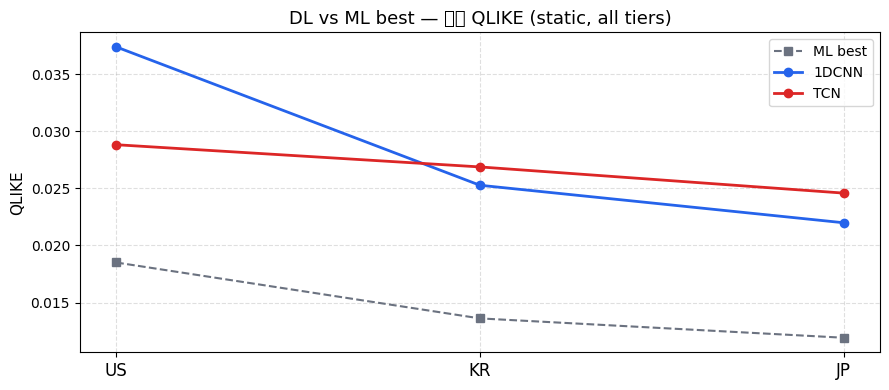

In [10]:
if ml.empty:
    print('ML 결과 없음 (ml_results_*.csv 미발견) — 이 셀은 생략합니다.')
else:
    # ML best per (country, feature_set, protocol)
    ml_agg = (
        ml.groupby(['country', 'feature_set', 'protocol'])['QLIKE']
        .min().reset_index().rename(columns={'QLIKE': 'ML_best_QLIKE'})
    )
    # DL per model
    dl_agg = (
        dl.groupby(['model', 'country', 'feature_set', 'protocol'])['QLIKE']
        .mean().reset_index()
    )
    merged = dl_agg.merge(ml_agg, on=['country', 'feature_set', 'protocol'], how='left')
    merged['vs_ML'] = merged['QLIKE'] - merged['ML_best_QLIKE']
    # 음수 = DL이 ML보다 나음

    summary = (
        merged.groupby(['model', 'protocol'])[['QLIKE', 'vs_ML']]
        .mean().round(6)
    )
    print('=== DL vs ML 비교 (vs_ML: 음수 = DL이 더 나음) ===')
    display(summary)

    # 시각화: static만
    sub_s = merged[merged['protocol'] == 'static']
    fig, ax = plt.subplots(figsize=(9, 4))
    x = np.arange(len(COUNTRIES))
    ax.plot(x, sub_s.groupby('country')['ML_best_QLIKE'].mean().reindex(COUNTRIES),
            color=ML_COLOR, ls='--', marker='s', lw=1.5, label='ML best', zorder=3)
    for m in available:
        m_sub = sub_s[sub_s['model'] == m]
        vals = m_sub.groupby('country')['QLIKE'].mean().reindex(COUNTRIES)
        ax.plot(x, vals, color=MODEL_COLOR.get(m, 'gray'),
                marker='o', lw=2, label=m, zorder=3)
    ax.set_xticks(x)
    ax.set_xticklabels(COUNTRIES, fontsize=12)
    ax.set_ylabel('QLIKE', fontsize=11)
    ax.set_title('DL vs ML best — 평균 QLIKE (static, all tiers)', fontsize=13)
    ax.legend(fontsize=10)
    ax.grid(linestyle='--', alpha=0.4)
    plt.tight_layout()
    fig.savefig(FIGURES_DIR / 'compare_vs_ml.png', dpi=150, bbox_inches='tight')
    plt.show()

## 셀 단위 산점도 — 1DCNN QLIKE vs TCN QLIKE

대각선 위 = TCN이 나음, 아래 = 1DCNN이 나음.

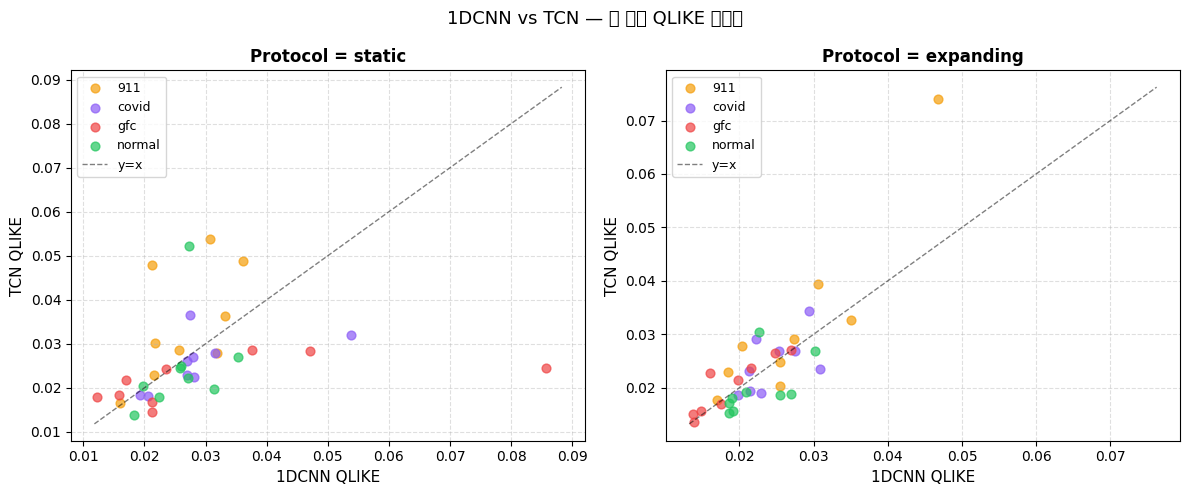

In [11]:
if all(m in available for m in ['1DCNN', 'TCN']):
    keys = ['regime', 'country', 'feature_set', 'protocol']
    sc_pivot = (
        dl[dl['model'].isin(['1DCNN', 'TCN'])]
        .groupby(['model'] + keys)['QLIKE']
        .mean()
        .unstack('model')
        .dropna(how='any')
        .reset_index()
    )

    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    for ax, prot in zip(axes, ['static', 'expanding']):
        sub = sc_pivot[sc_pivot['protocol'] == prot]
        if sub.empty:
            ax.set_title(f'{prot} (없음)')
            continue

        # 색: regime
        regime_colors = {'normal': '#22C55E', '911': '#F59E0B',
                         'gfc': '#EF4444', 'covid': '#8B5CF6'}
        for regime, grp in sub.groupby('regime'):
            ax.scatter(grp['1DCNN'], grp['TCN'],
                       color=regime_colors.get(regime, 'gray'),
                       label=regime, alpha=0.7, s=40)

        lo = min(sub['1DCNN'].min(), sub['TCN'].min()) * 0.97
        hi = max(sub['1DCNN'].max(), sub['TCN'].max()) * 1.03
        ax.plot([lo, hi], [lo, hi], 'k--', lw=1, alpha=0.5, label='y=x')
        ax.set_xlabel('1DCNN QLIKE', fontsize=11)
        ax.set_ylabel('TCN QLIKE', fontsize=11)
        ax.set_title(f'Protocol = {prot}', fontsize=12, fontweight='bold')
        ax.legend(fontsize=9)
        ax.grid(linestyle='--', alpha=0.4)

    fig.suptitle('1DCNN vs TCN — 셀 단위 QLIKE 산점도', fontsize=13)
    plt.tight_layout()
    fig.savefig(FIGURES_DIR / 'compare_scatter.png', dpi=150, bbox_inches='tight')
    plt.show()
else:
    print('두 모델 결과 모두 필요합니다.')

## 종합 판정

자동 출력 — 어떤 모델을 최종 DL 후보로 쓸지 판단 근거.

In [12]:
print('=' * 60)
print('  종합 판정 (QLIKE 기준, 낮을수록 우수)')
print('=' * 60)

for prot in ['static', 'expanding']:
    sub = dl[dl['protocol'] == prot]
    if sub.empty:
        print(f'\n[{prot.upper()}] 데이터 없음')
        continue

    print(f'\n[{prot.upper()}]')
    for m in available:
        q = sub[sub['model'] == m]['QLIKE'].mean()
        print(f'  {m:8s}: 평균 QLIKE = {q:.6f}')

    # 승자
    if all(m in available for m in ['1DCNN', 'TCN']):
        q_1d  = sub[sub['model'] == '1DCNN']['QLIKE'].mean()
        q_tcn = sub[sub['model'] == 'TCN']['QLIKE'].mean()
        diff  = abs(q_1d - q_tcn)
        if diff < 1e-4:
            print(f'  → 두 모델 거의 동등 (차이 {diff:.2e})')
        elif q_1d < q_tcn:
            print(f'  → 1DCNN 우수 (QLIKE 차이 {diff:.4f})')
        else:
            print(f'  → TCN 우수  (QLIKE 차이 {diff:.4f})')

print('\n' + '=' * 60)
print('모든 차트 저장 위치:', FIGURES_DIR)

  종합 판정 (QLIKE 기준, 낮을수록 우수)

[STATIC]
  1DCNN   : 평균 QLIKE = 0.028209
  TCN     : 평균 QLIKE = 0.026754
  → TCN 우수  (QLIKE 차이 0.0015)

[EXPANDING]
  1DCNN   : 평균 QLIKE = 0.023280
  TCN     : 평균 QLIKE = 0.024248
  → 1DCNN 우수 (QLIKE 차이 0.0010)

모든 차트 저장 위치: /content/drive/MyDrive/FINTEL/results/figures
